In [4]:
import numpy as np
import pandas as pd
from tqdm import trange
import os
import re
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'values' from string to real numpy arrays
def parse_values(val):
    if isinstance(val, str):
        # Remove square brackets and split by whitespace
        val = val.strip().strip("[]").strip(",")
        # Handle empty entries gracefully
        if not val:
            return np.array([])
        # Split on whitespace and convert to float
        return np.array([float(x) for x in re.split(r"\s+", val.strip())])
    elif isinstance(val, (list, np.ndarray)):
        return np.array(val)
    else:
        return np.array([])



# ===================================================================================================
folder_path = "data"
# ===================================================================================================


metric_names = [
    "first_pca_component",
    # "first_pca_component_velocity_alignment",
    "first_pca_component_horizontal_axis_alignment",
    # "first_pca_component_z_axis_alignment",
    "second_pca_component",
    "second_pca_component_velocity_alignment",
    # "second_pca_component_horizontal_axis_alignment",
    # "second_pca_component_z_axis_alignment",
    # "normalized_velocity_alignment",
    # "velocity_deviation",
    # "sidewise_acceleration_deviation",
    # "longitudinal_acceleration_deviation",
    "gaussian_entropy",
    "parallel_deviation",
    "lateral_deviation",
    "vertical_deviation",
]

dfs = {}

for metric in metric_names:
    filepath = folder_path + '/' + metric + '_df.csv'
    metric_df = pd.read_csv(filepath, index_col=0)
    # metric_df['values'] = metric_df['values'].apply(parse_values)
    metric_df['values'] = np.array(metric_df['values'].apply(ast.literal_eval))
    dfs[metric] = metric_df


In [5]:
metric_arrays = {}

for metric in metric_names:
    metric_df = dfs[metric]
    arrays = [np.array(v, dtype=float) for v in metric_df['values']
    if isinstance(v, (list, np.ndarray))]

    values = np.concatenate(arrays)
    metric_arrays[metric] = values

In [6]:
def plot_hist(values: np.ndarray, name: str, limits=None, percentile=False):
    """Plot a pretty histogram"""

    values = values[np.isfinite(values)]
    mean = np.mean(values)
    median = np.median(values)
    std_dev = np.std(values)
    percentile = np.percentile(values, 95)


    fig = plt.figure(figsize=(8, 6), dpi=300)

    ax = sns.histplot(values, color="blue", kde=True, zorder=2)


    for line in ax.lines:
        line.set_color('crimson')
        
    plt.grid(color="lightgrey", zorder=0)

    ax.axvline(median, color='green', label='median', linestyle='--', zorder=3)
    ax.axvline(mean, color='orange', label='mean', linestyle='-', zorder=3)
    ax.axvspan(mean - std_dev, mean + std_dev, color='orange', alpha=0.2, zorder=1, label='±1 std_dev')
    if percentile == True:
        ax.axvline(percentile, color='lightblue', label='95% percentile', linestyle='-', zorder=3)

    if limits is not None:
        ax.set_xlim(limits[0], limits[1])

    # figure prettiness
    plt.title(f'Distribution of {name}')
    plt.xlabel(f'{name[:-1]}')
    plt.ylabel('count')
    plt.legend()

    plt.tight_layout()

    plt.show()


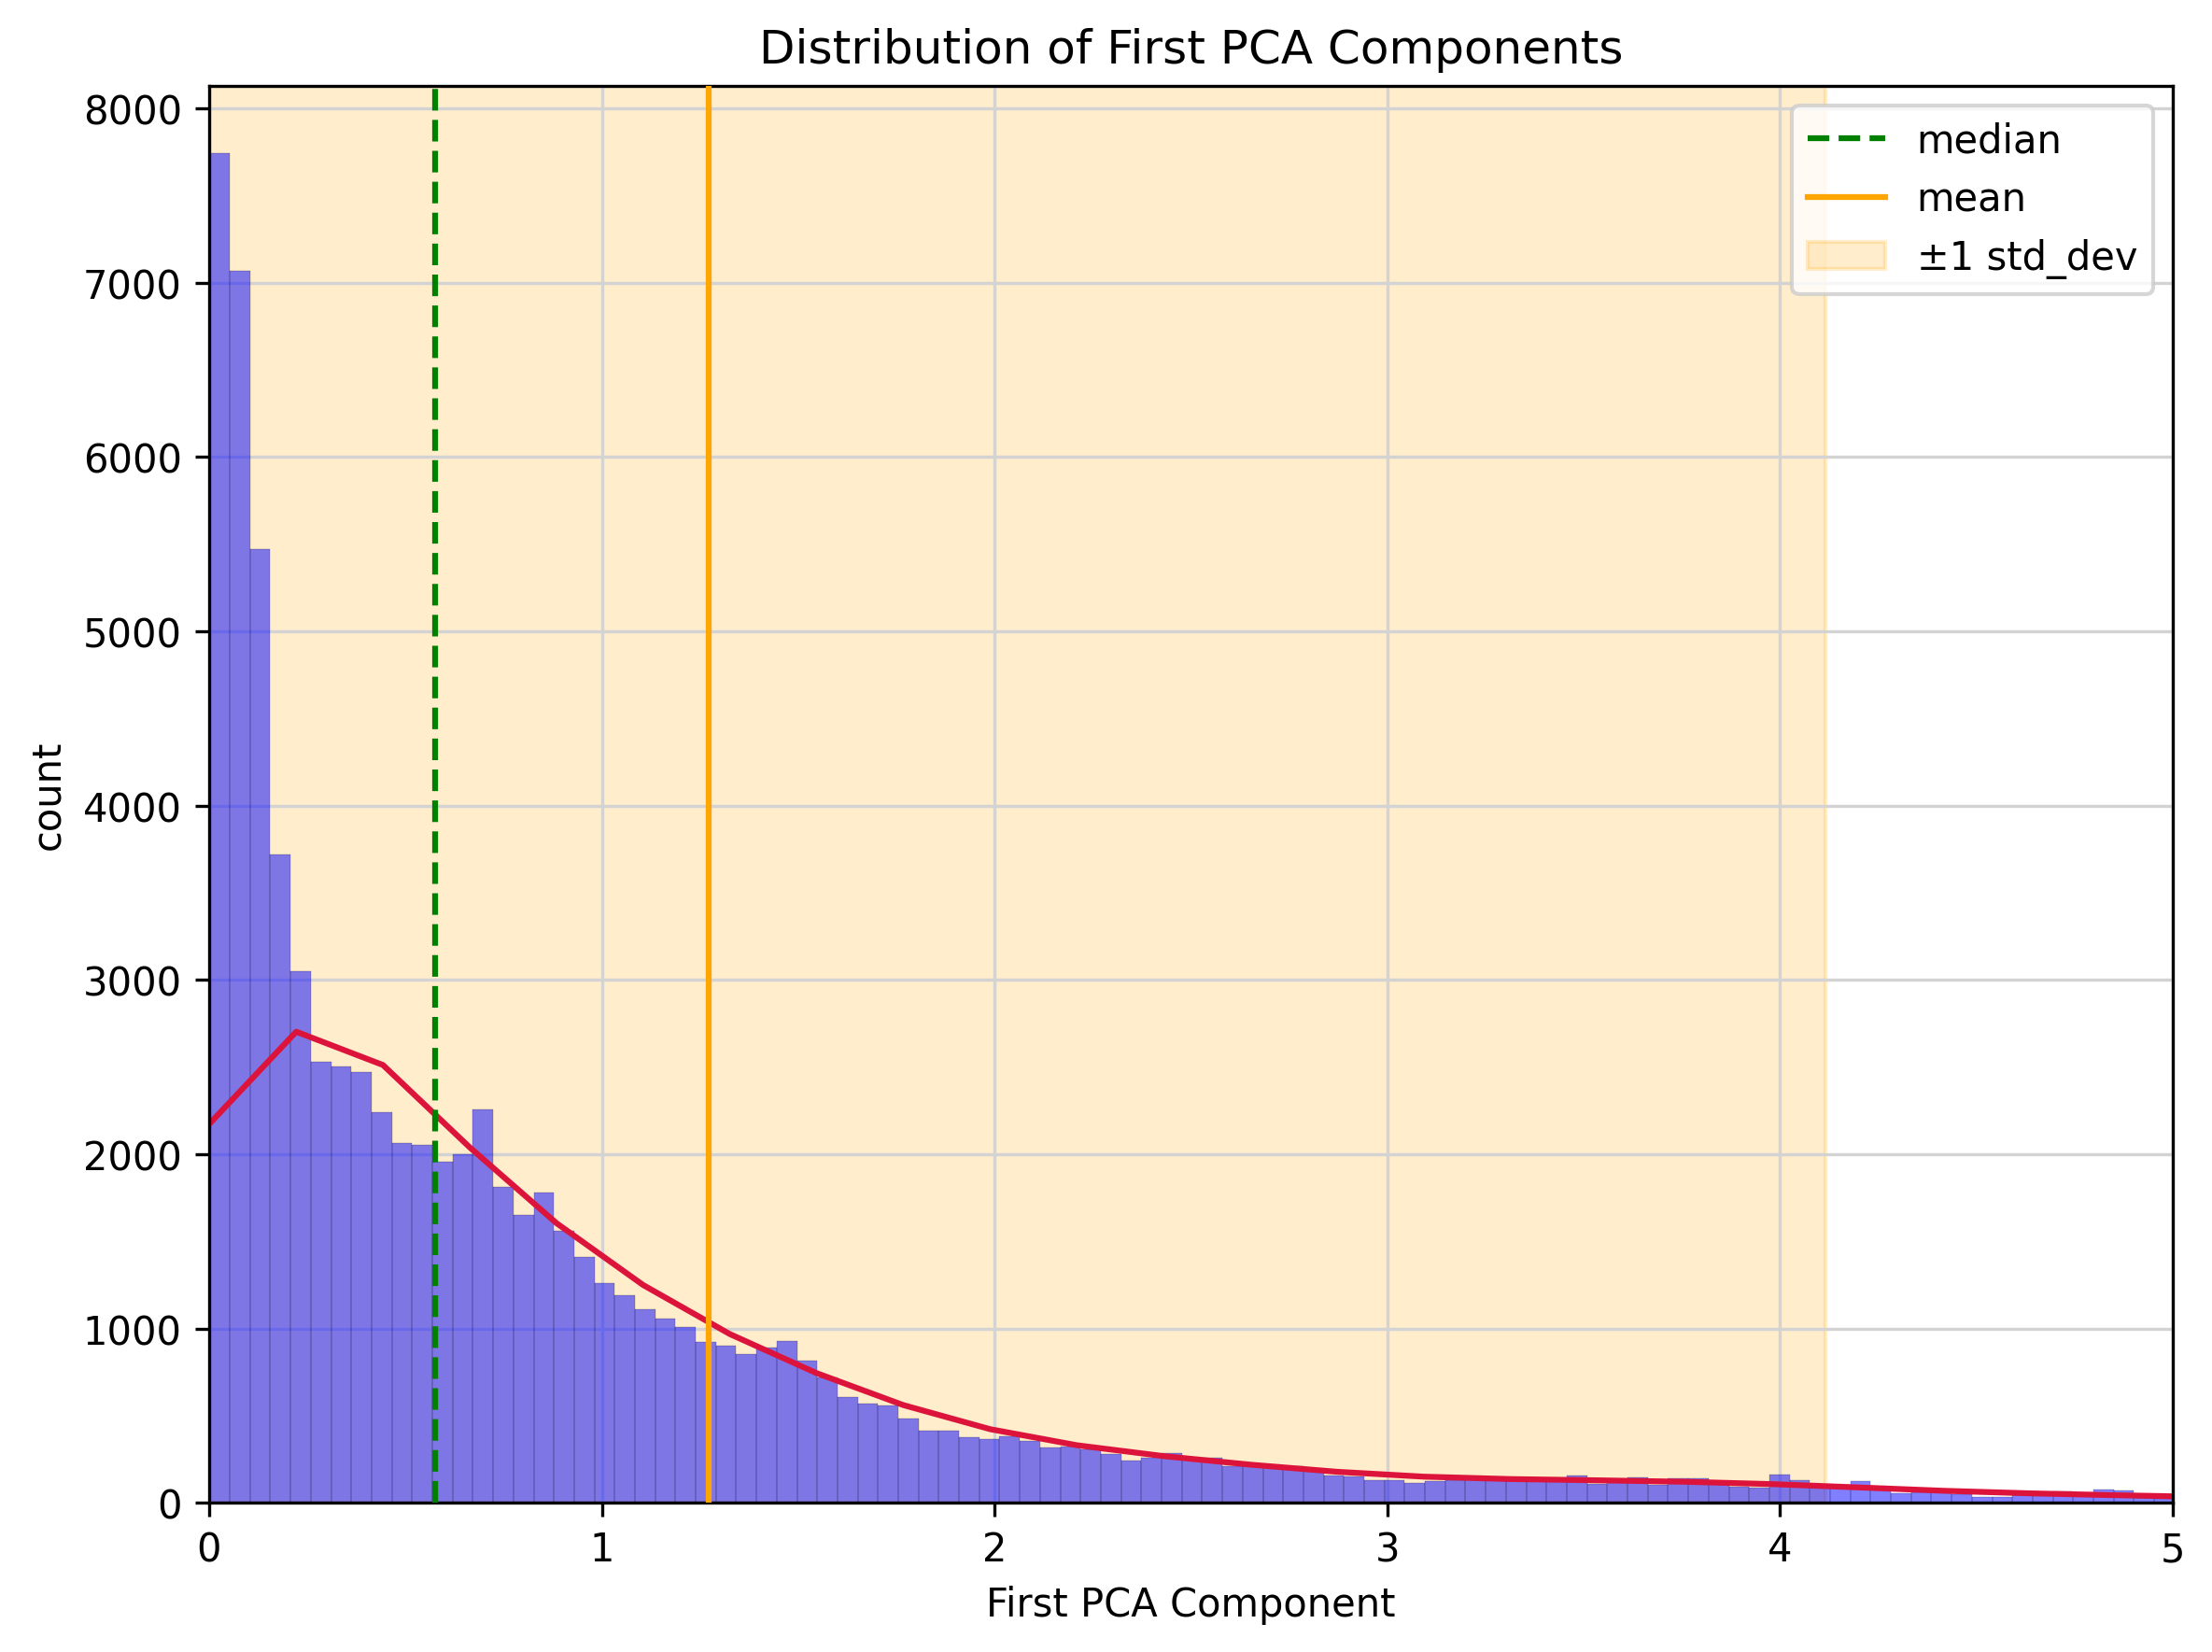

In [7]:
plot_hist(metric_arrays["first_pca_component"], "First PCA Components", limits=[0, 5])

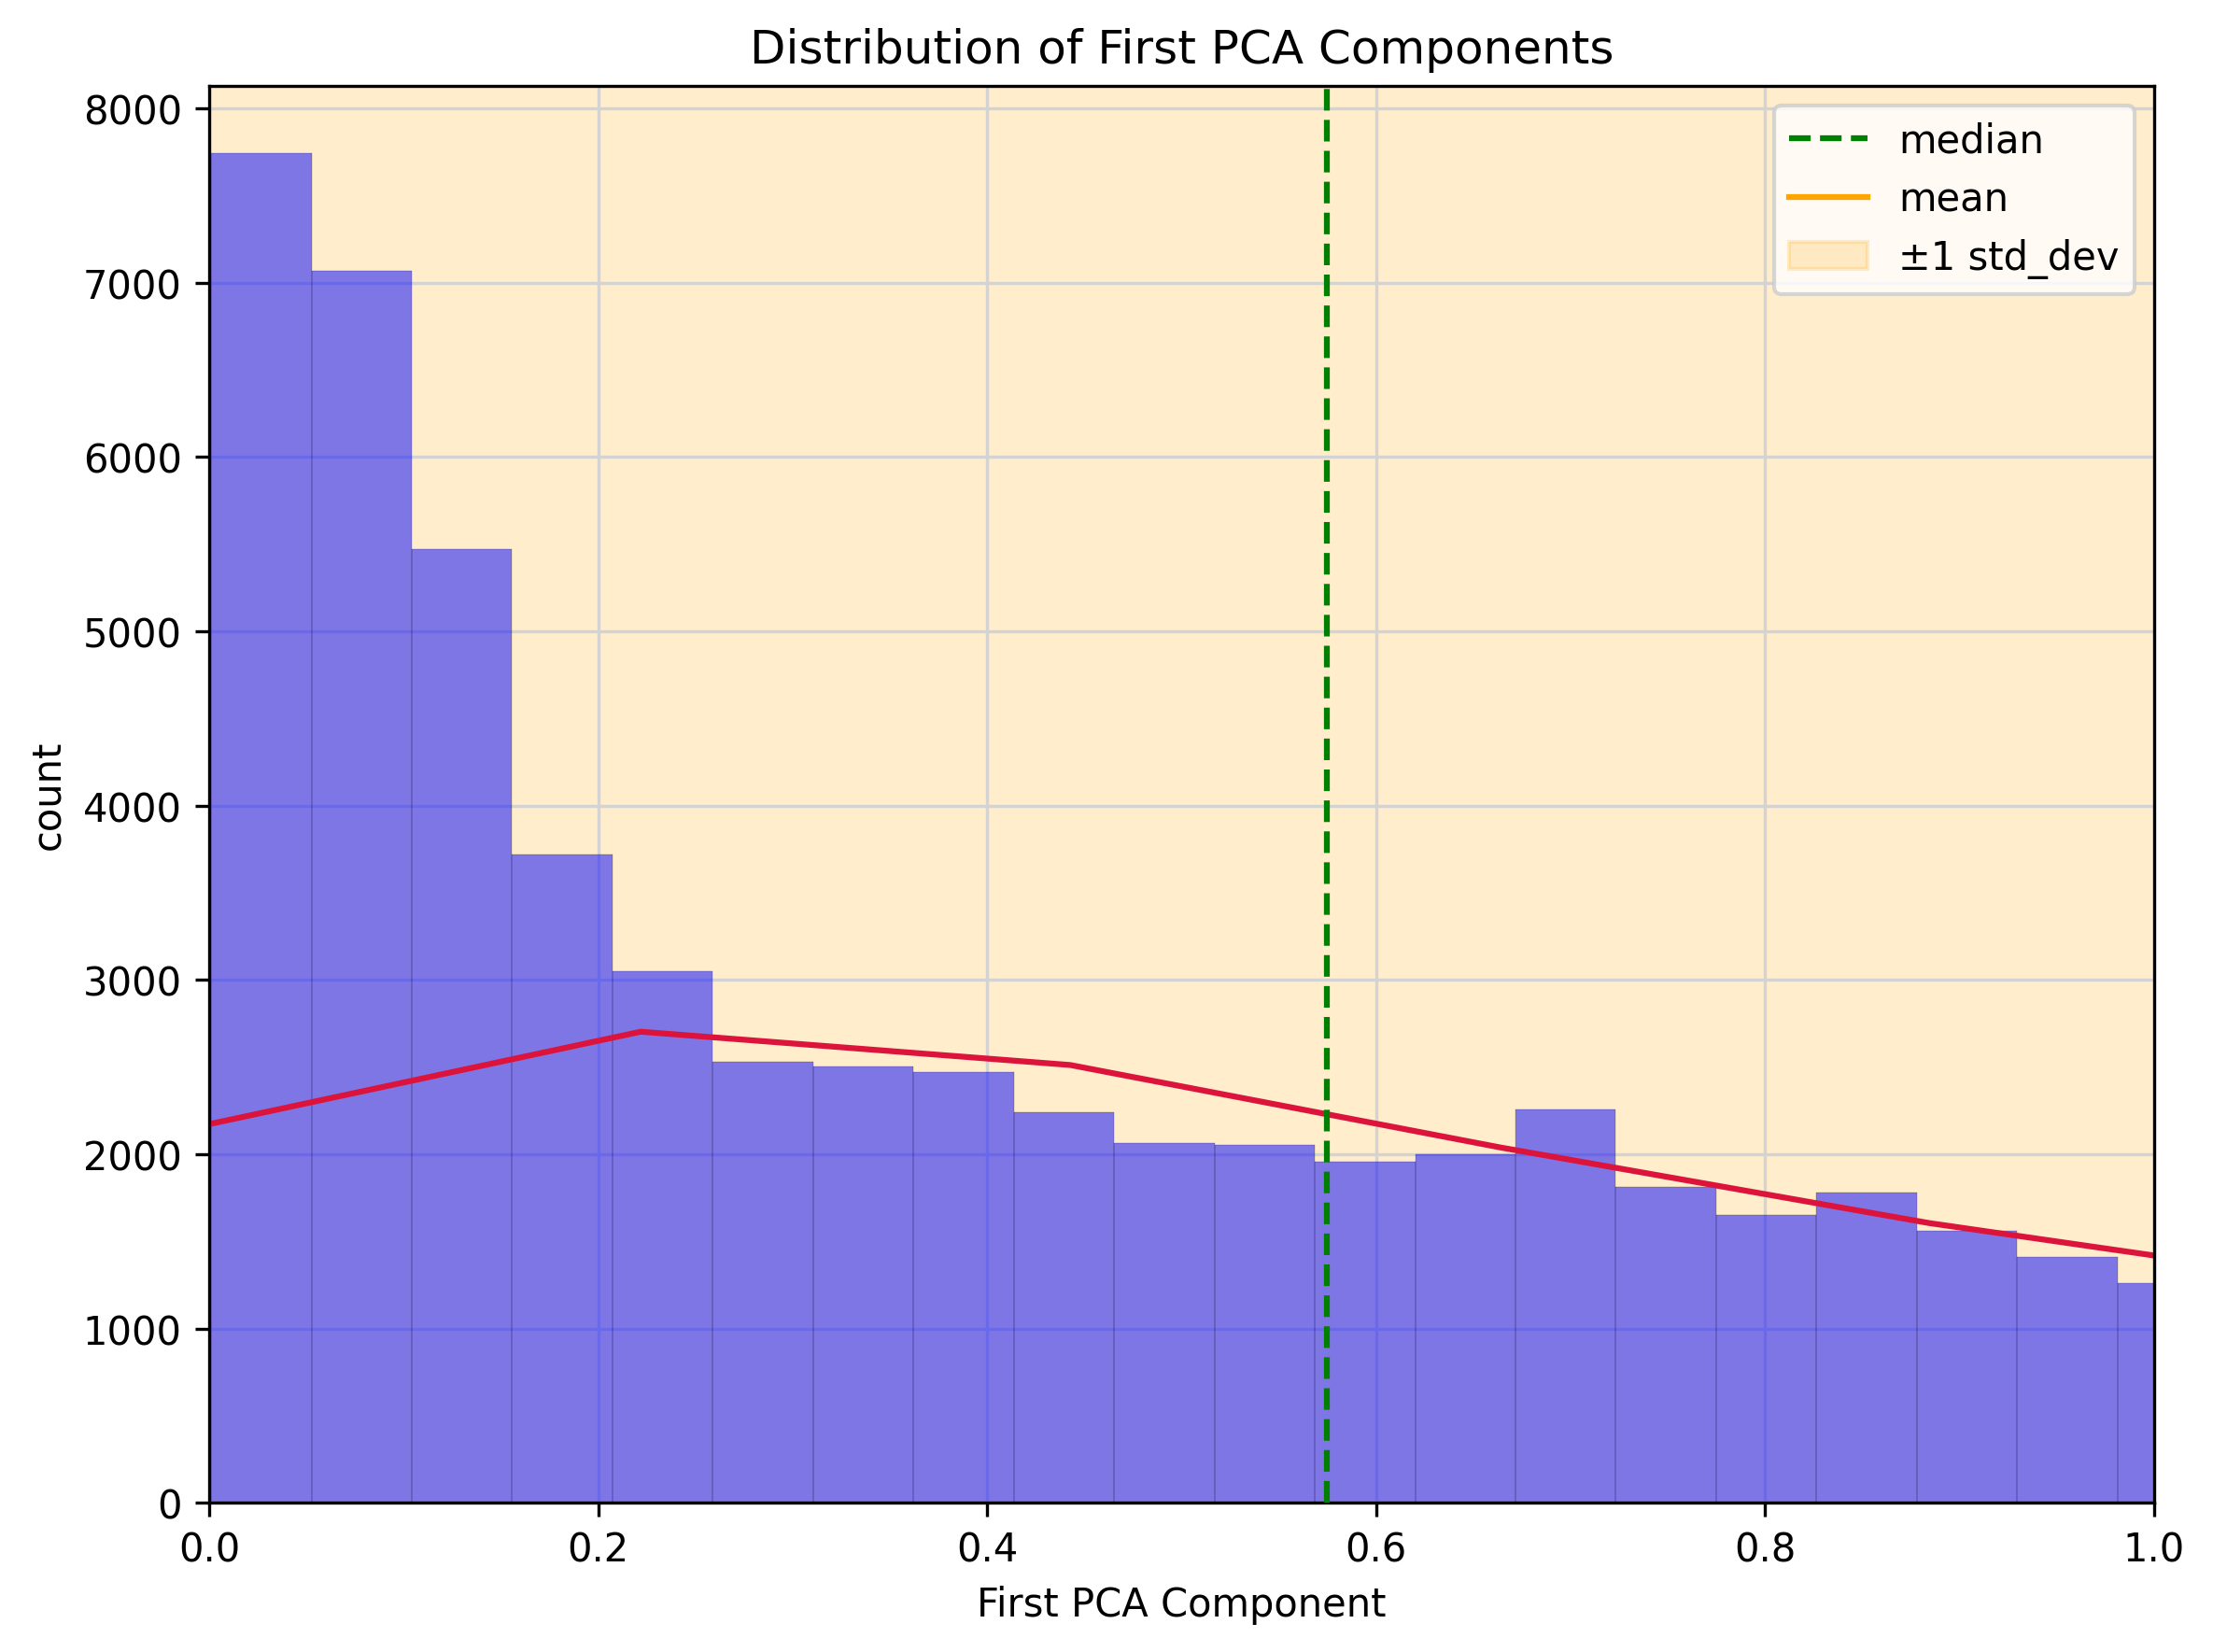

In [8]:
plot_hist(metric_arrays["first_pca_component"], "First PCA Components", limits=[0, 1])

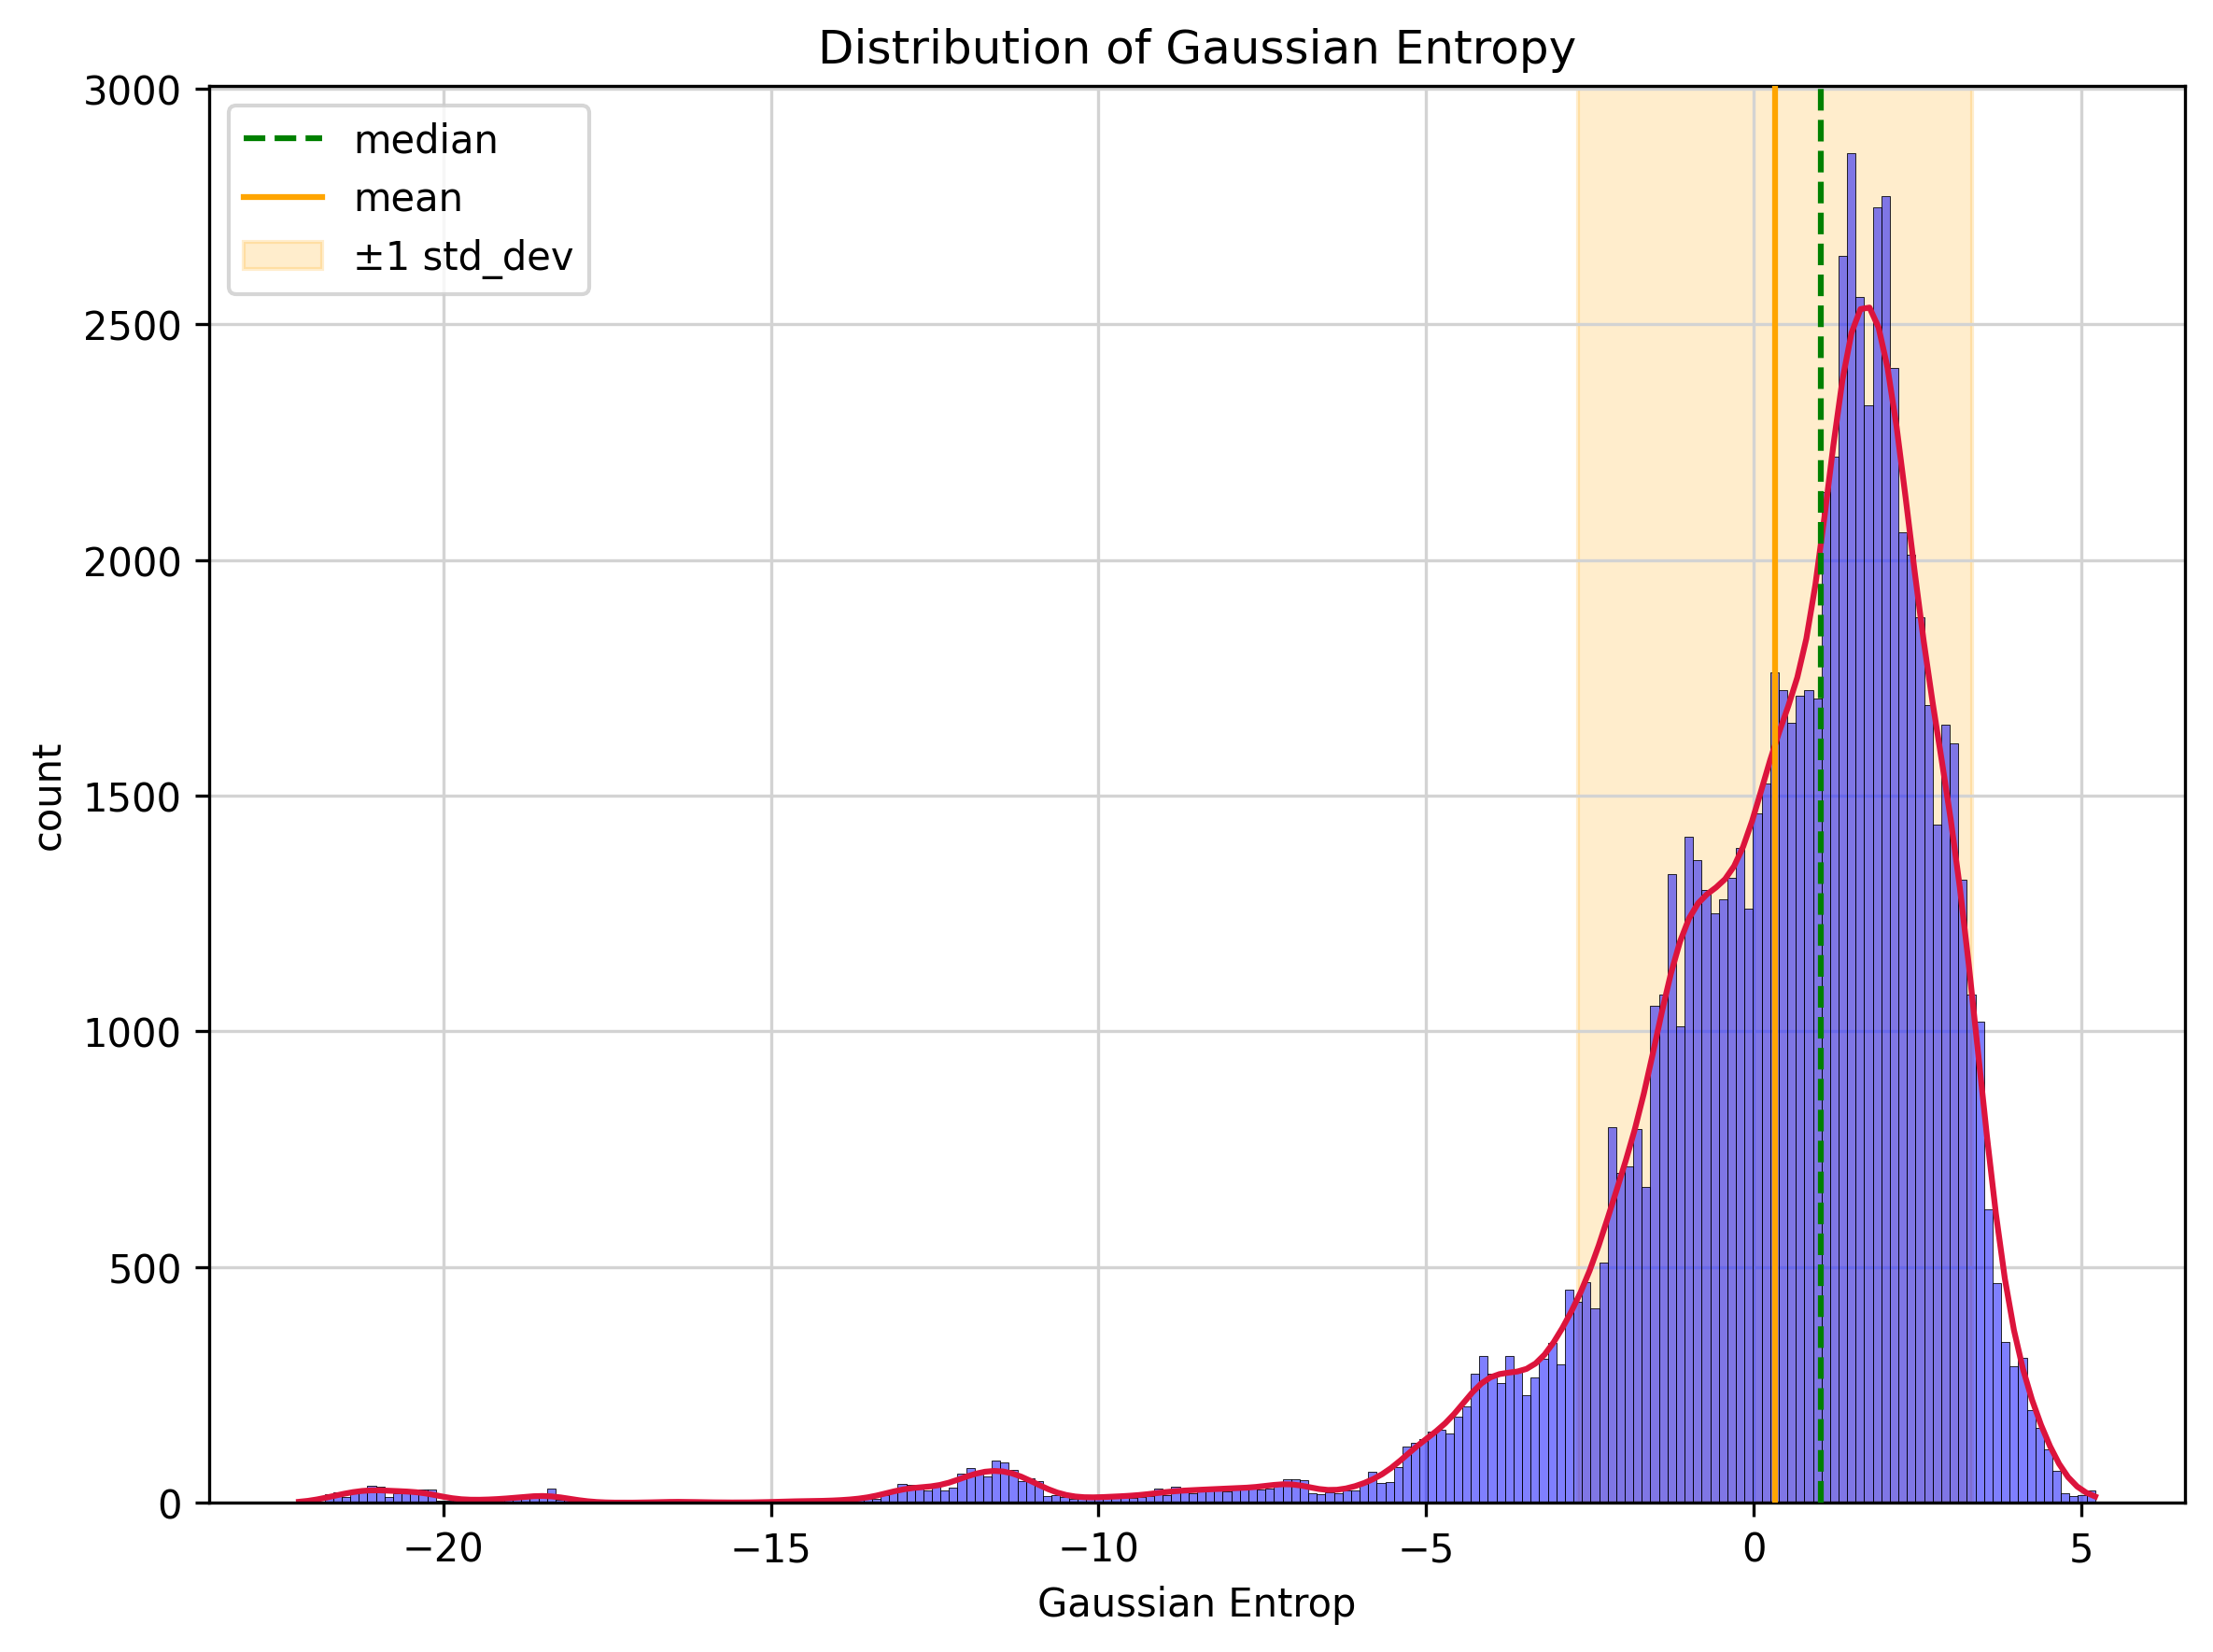

In [9]:
plot_hist(metric_arrays["gaussian_entropy"], "Gaussian Entropy")

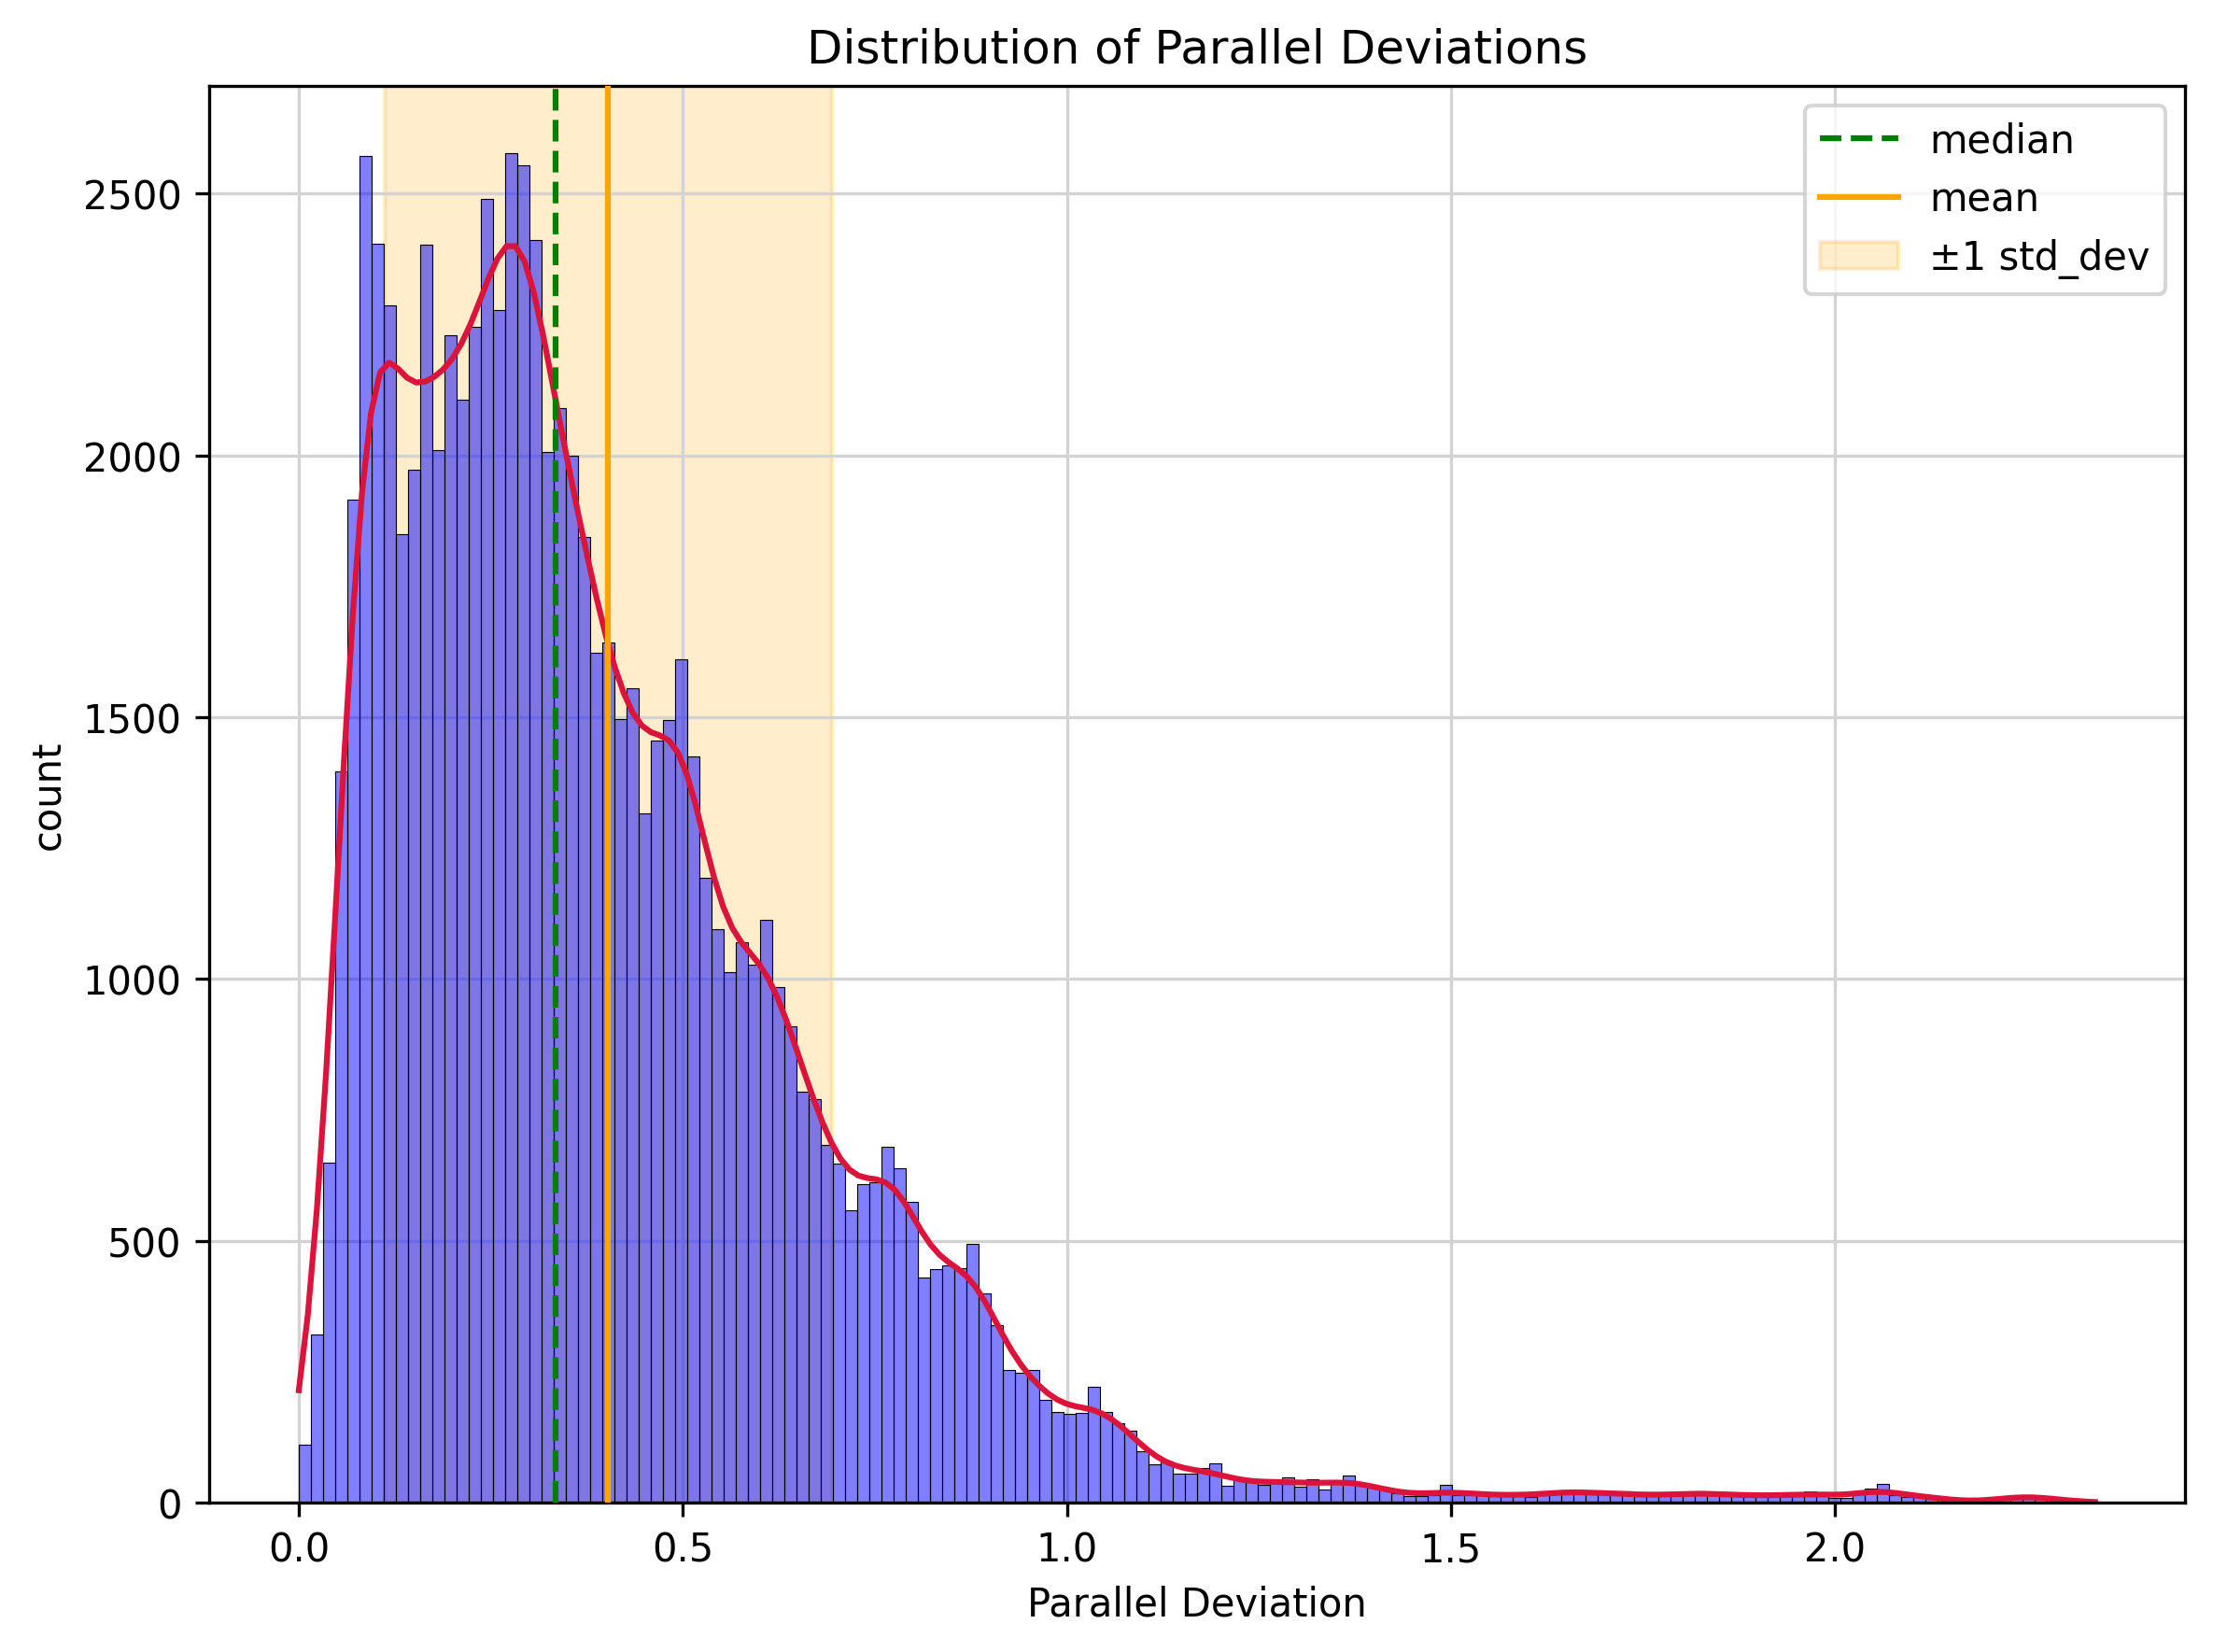

In [10]:
plot_hist(metric_arrays["parallel_deviation"], "Parallel Deviations")

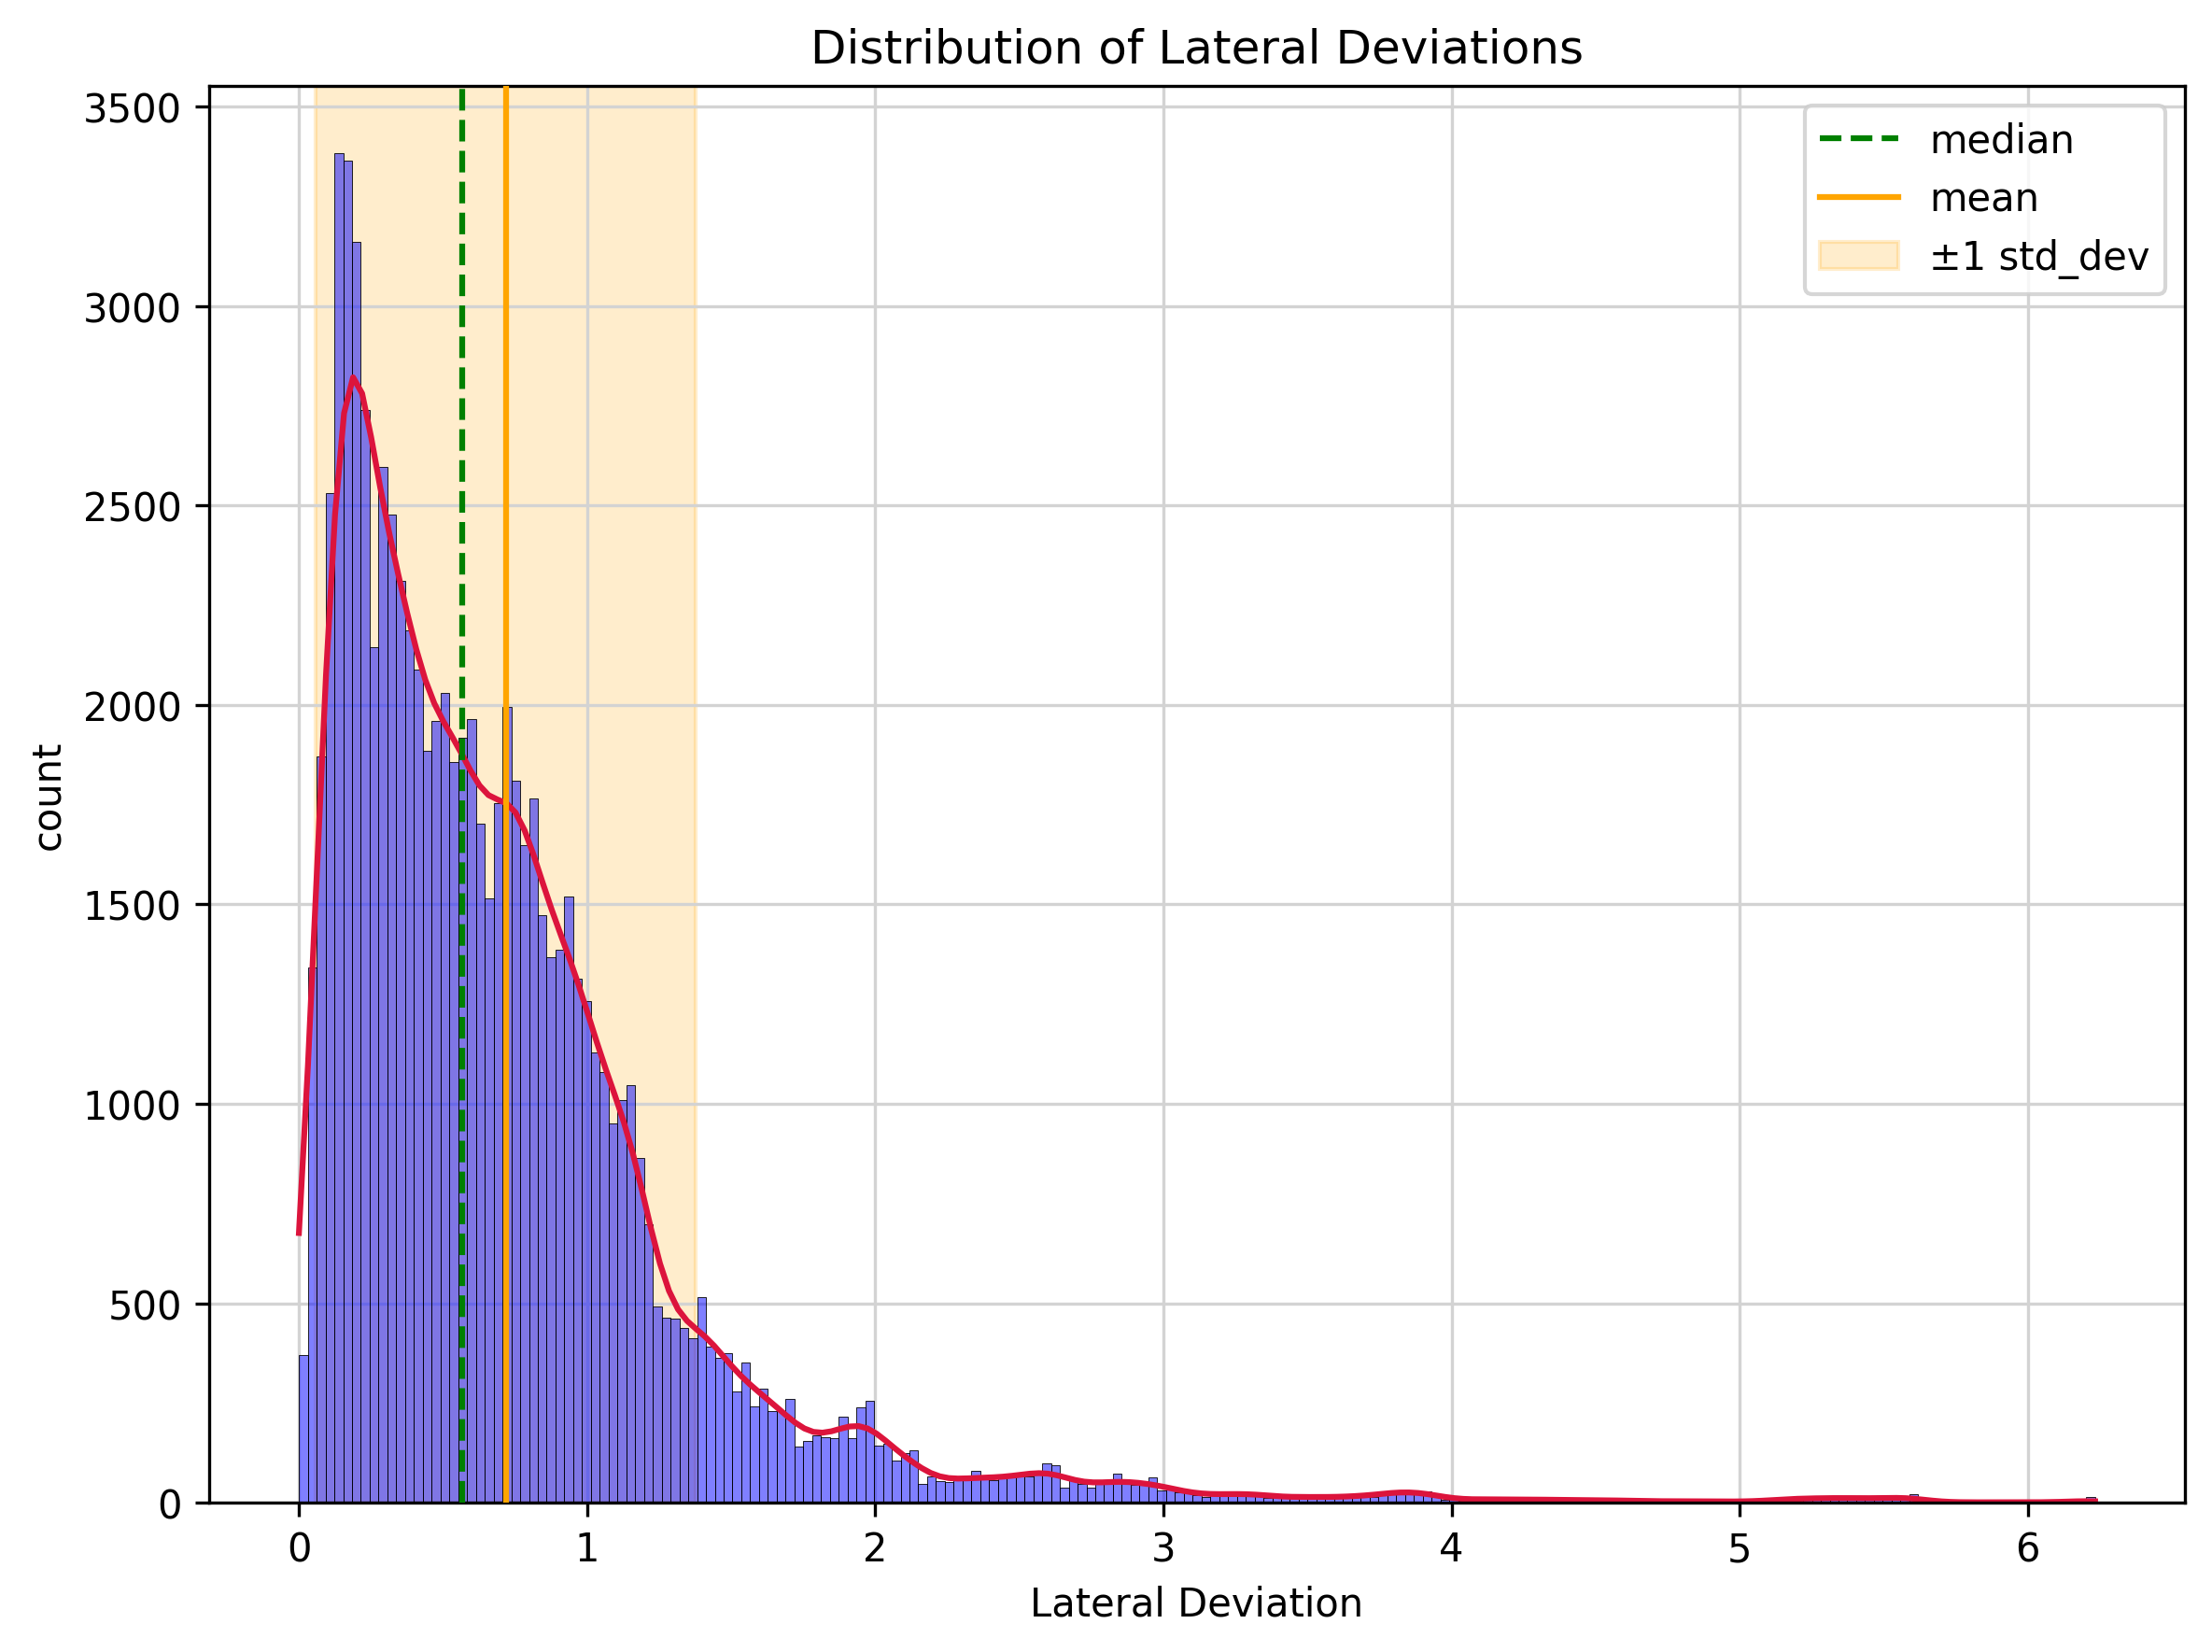

In [13]:
plot_hist(metric_arrays["lateral_deviation"], "Lateral Deviations")

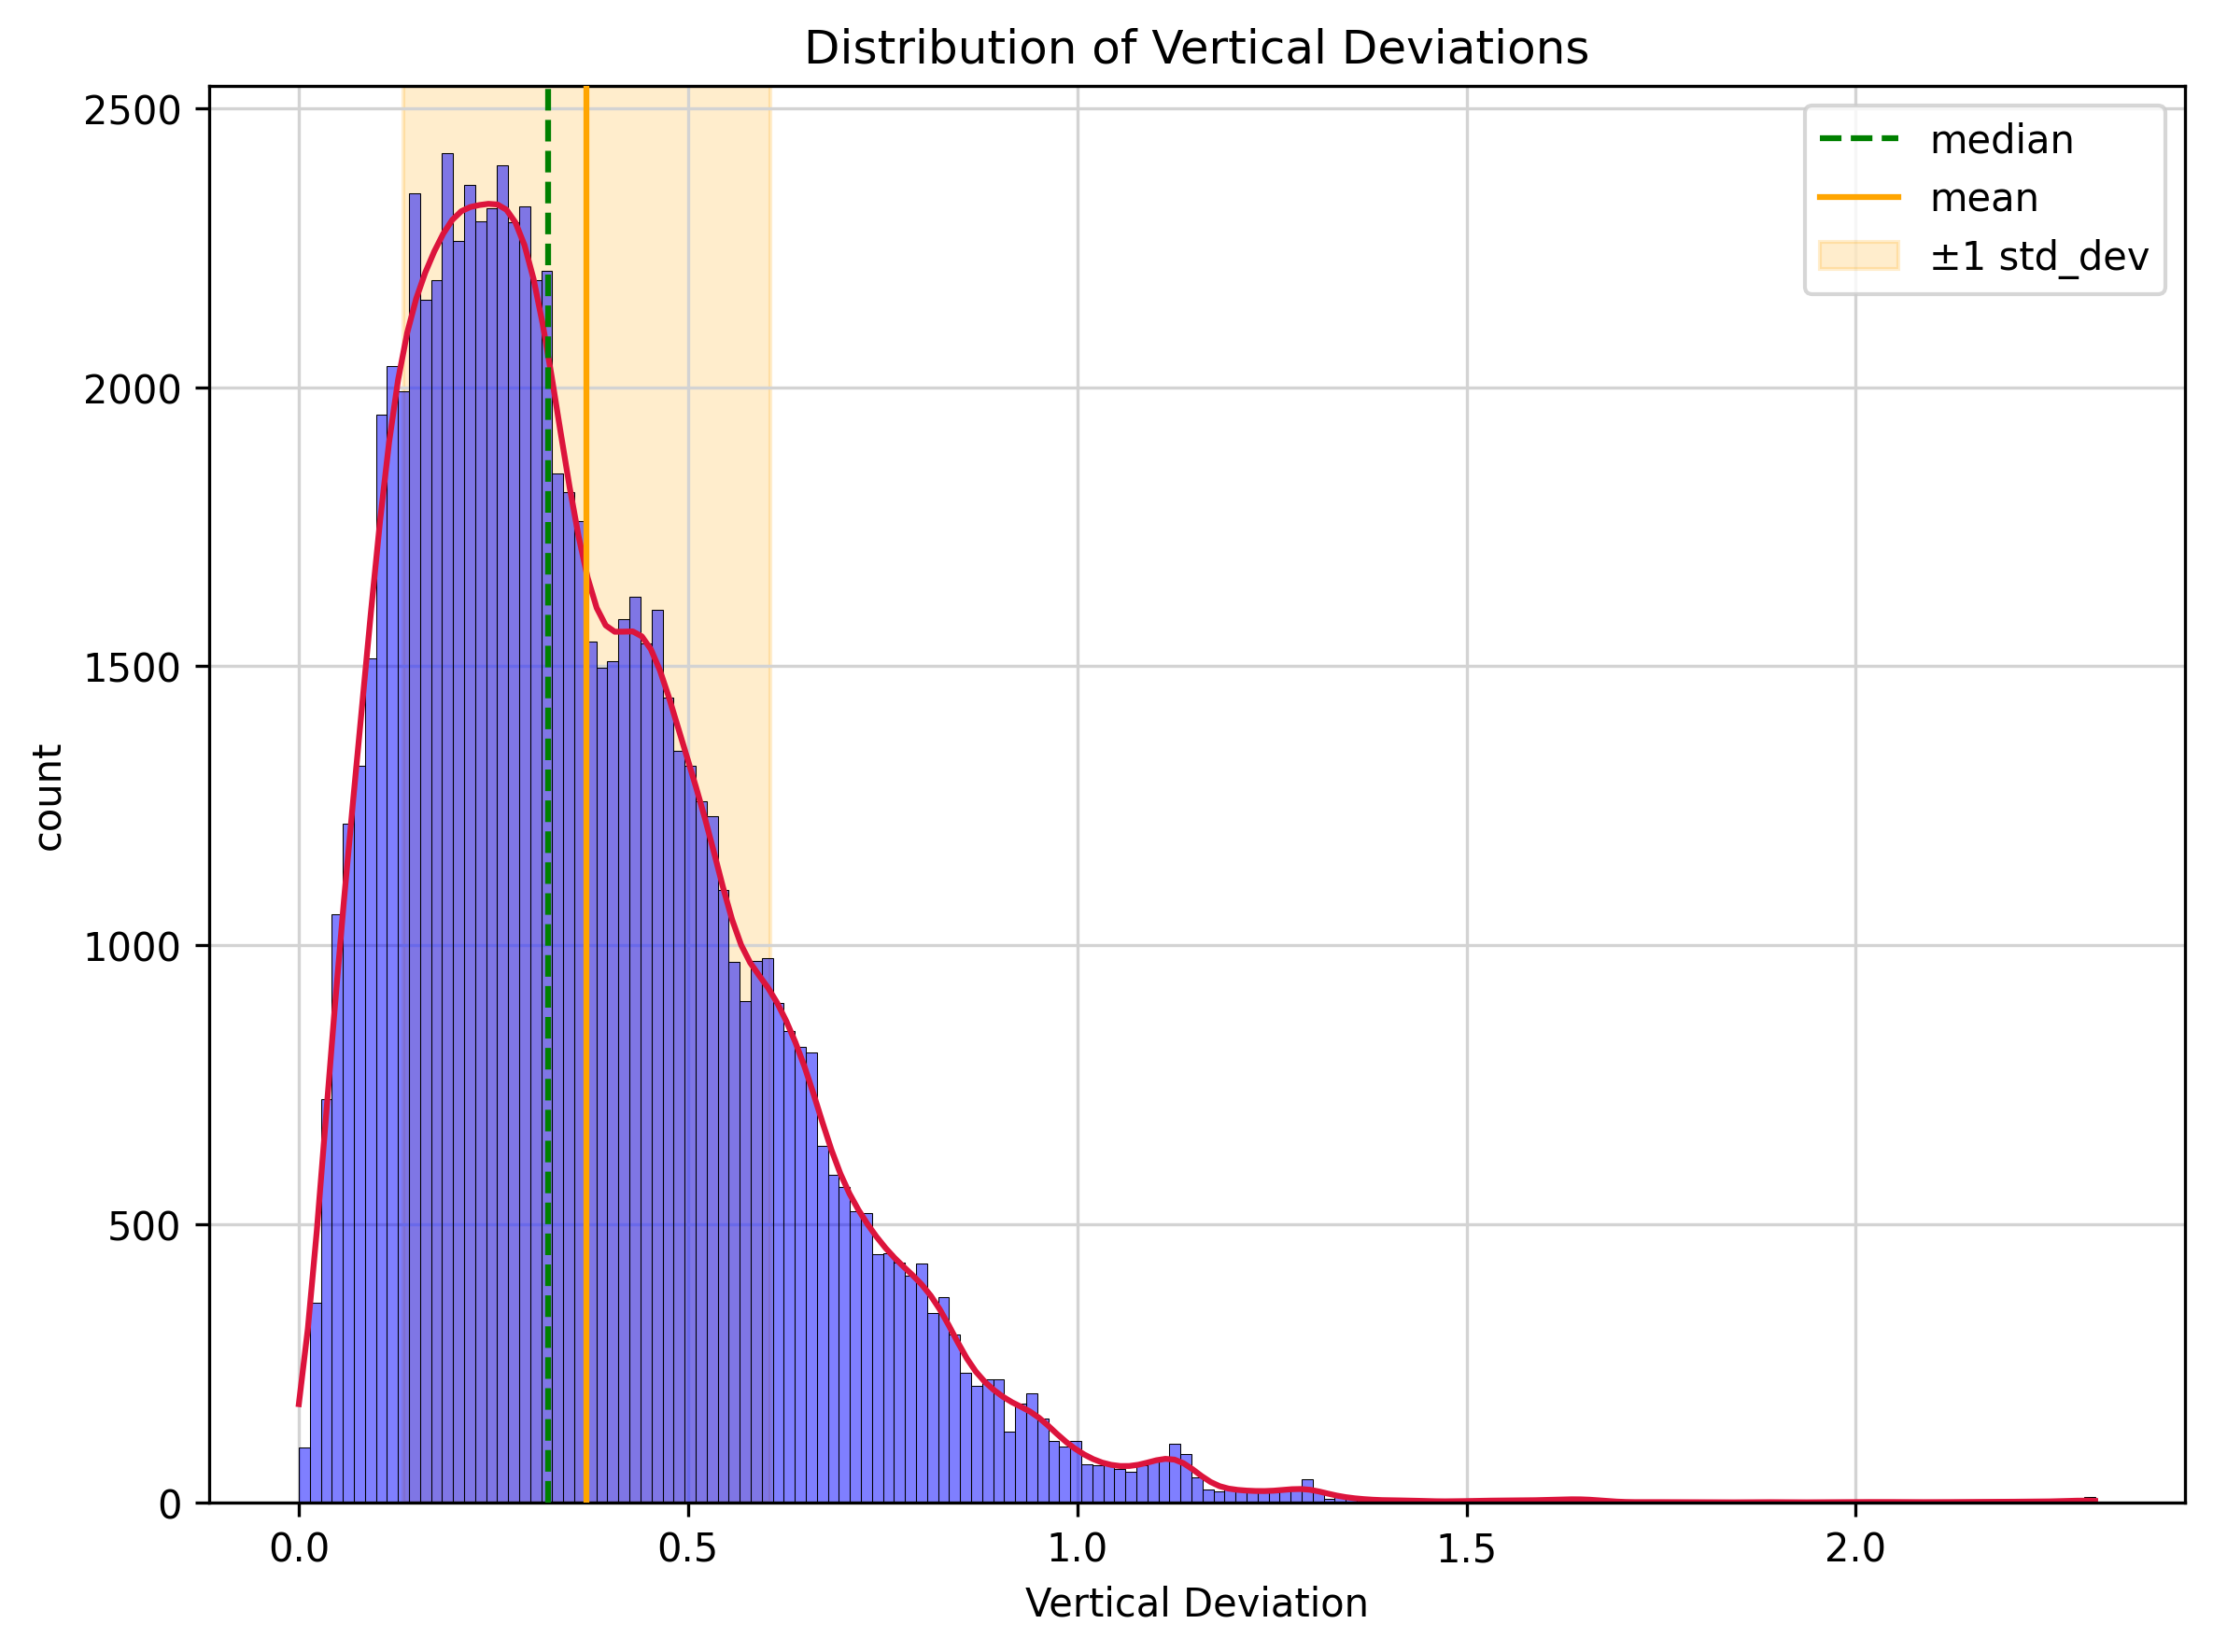

In [14]:
plot_hist(metric_arrays["vertical_deviation"], "Vertical Deviations")